# Thesis Figure 11 Ã¢â‚¬â€ Multiple Regions + Seed Selection

**Part A Ã¢â‚¬â€ Multiple Regions Overlay**
Shows how CIAO explains an image using three simultaneous regions.
Outputs:
1. `original` Ã¢â‚¬â€ the raw input image.
2. `all_regions` Ã¢â‚¬â€ all three regions overlaid at once, each in a distinct configurable colour.

Source: MLflow run `ucb-3regions-42-length-20`, child `imagenets_0067.jpg`.

**Part B Ã¢â‚¬â€ Seed Selection Heatmap**
Runs the initial segment scoring scan and visualises the seed segment and its frontier neighbours.
Outputs:
3. `seed_selection` Ã¢â‚¬â€ score heatmap with Ã¢Ëœâ€¦ seed and Ã¢â€”Â neighbours.
4. `seed_selection_boundaries` Ã¢â‚¬â€ same with segment boundaries visible.

Edit only the **Configuration** cell.

In [11]:
# Ã¢â€â‚¬Ã¢â€â‚¬ Configuration Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
IMAGE_PATH = r"REPO_ROOT/images\images\imagenets_0067.jpg"

TRACKING_URI = "https://mlflow.rationai.cloud.e-infra.cz/"
MLFLOW_USER = "YOUR_MLFLOW_USERNAME"
MLFLOW_PASSWORD = "YOUR_MLFLOW_PASSWORD"
EXPERIMENT_NAME = "ucb-multiple-regions"
PARENT_RUN_NAME = "ucb-3regions-42-length-20"
CHILD_RUN_NAME = "imagenets_0067.jpg"

SEG_OVERRIDES = [
    "segmentation=hexagonal",
]

# Ã¢â€â‚¬Ã¢â€â‚¬ Part A: region overlay colours Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
# Colours for region 0, 1, 2 (matplotlib-compatible)
REGION_COLORS = ["#e63946", "#2a9d8f", "#e9c46a"]  # red, teal, amber
REGION_ALPHA = 0.55
NUM_REGIONS = 3

# Ã¢â€â‚¬Ã¢â€â‚¬ Part B: seed selection Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
TARGET_CLASS_IDX = None  # None Ã¢â€ â€™ model's top-1
SIGMA = 1  # 1=positive seed, -1=negative, None=max|score|
NEIGHBORHOOD_DIST = 1
BATCH_SIZE = 16
SCORE_ALPHA = 0.55
SEED_MARKER_SIZE = 18
NEIGHBOR_MARKER_SIZE = 10

OUTPUT_DIR = "output/11_multiple_regions"

In [12]:
import json
import os
import sys
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import torch
from hydra import compose, initialize_config_dir
from hydra.core.global_hydra import GlobalHydra
from hydra.utils import instantiate
from matplotlib.colors import to_rgba


REPO_ROOT = Path("../..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from ciao.algorithm.builder import _select_seed_and_sign
from ciao.data.preprocessing import load_and_preprocess_image
from ciao.model.predictor import ModelPredictor
from ciao.scoring.region import log_odds_for_class
from ciao.scoring.segments import calculate_segment_scores, create_surrogate_dataset
from ciao.visualization.visualization import _segment_boundaries, _to_hwc


os.environ["MLFLOW_TRACKING_USERNAME"] = MLFLOW_USER
os.environ["MLFLOW_TRACKING_PASSWORD"] = MLFLOW_PASSWORD
mlflow.set_tracking_uri(TRACKING_URI)

OUT = Path(OUTPUT_DIR)
OUT.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}  |  repo: {REPO_ROOT}")

device: cpu  |  repo: REPO_ROOT/n

In [13]:
# Ã¢â€â‚¬Ã¢â€â‚¬ Fetch segment lists from MLflow Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
client = mlflow.tracking.MlflowClient()

exp = client.get_experiment_by_name(EXPERIMENT_NAME)
assert exp is not None, f"Experiment {EXPERIMENT_NAME!r} not found."

parent_runs = mlflow.search_runs(
    experiment_ids=[exp.experiment_id],
    filter_string=f"tags.`mlflow.runName` = '{PARENT_RUN_NAME}'",
    output_format="pandas",
)
assert len(parent_runs) == 1, f"Expected 1 parent run, got {len(parent_runs)}."
parent_run_id = parent_runs.iloc[0]["run_id"]
print(f"Parent run: {parent_run_id}")

child_runs = mlflow.search_runs(
    experiment_ids=[exp.experiment_id],
    filter_string=(
        f"tags.`mlflow.parentRunId` = '{parent_run_id}' "
        f"AND tags.`mlflow.runName` = '{CHILD_RUN_NAME}'"
    ),
    output_format="pandas",
)
assert len(child_runs) == 1, f"Expected 1 child run, got {len(child_runs)}."
child_run_id = child_runs.iloc[0]["run_id"]
print(f"Child run : {child_run_id}")

region_segments: list[list[int]] = []
with tempfile.TemporaryDirectory() as tmp:
    for i in range(NUM_REGIONS):
        path = client.download_artifacts(child_run_id, f"region_{i}/segments.json", tmp)
        with open(path) as f:
            data = json.load(f)
        region_segments.append(data["segments"])
        print(f"region_{i}: {len(data['segments'])} segments")

Parent run: 6106f876fc1841d38e6881b6763f3b4b
Child run : 03ef4bc84e074a4dbcb7ada3f2fa0049


region_0: 20 segments


region_1: 20 segments


region_2: 1 segments


In [14]:
# Ã¢â€â‚¬Ã¢â€â‚¬ Load image, segmentation and model via Hydra Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
GlobalHydra.instance().clear()
with initialize_config_dir(config_dir=str(REPO_ROOT / "configs"), version_base=None):
    cfg = compose(
        config_name="base", overrides=SEG_OVERRIDES + ["replacement=imagenet_mean"]
    )

img_tensor = load_and_preprocess_image(IMAGE_PATH, device=device)
input_batch = img_tensor.unsqueeze(0)

segmentation_fn = instantiate(cfg.segmentation)
image_graph = segmentation_fn(img_tensor)

model = instantiate(cfg.model).to(device).eval()
class_names = instantiate(cfg.classes)
predictor = ModelPredictor(model=model, class_names=class_names)

replacement_fn = instantiate(cfg.replacement)
replacement_image = replacement_fn(img_tensor)

img_np = _to_hwc(input_batch)  # [H, W, 3] float32 in [0, 1]
segs = image_graph.segments.cpu().numpy()  # [H, W] int32

print(f"Image shape : {img_np.shape}")
print(f"Segments    : {image_graph.num_segments} unique IDs")

Image shape : (224, 224, 3)
Segments    : 1273 unique IDs


In [15]:
# Ã¢â€â‚¬Ã¢â€â‚¬ Build per-region binary masks Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
region_masks: list[np.ndarray] = []
for seg_ids in region_segments:
    mask = np.zeros(segs.shape, dtype=np.float32)
    for sid in seg_ids:
        mask[segs == sid] = 1.0
    region_masks.append(mask)
    print(f"pixels covered: {int(mask.sum())} / {mask.size}")

pixels covered: 836 / 50176
pixels covered: 831 / 50176
pixels covered: 43 / 50176


In [16]:
# Ã¢â€â‚¬Ã¢â€â‚¬ Helpers Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
def save(fig: plt.Figure, stem: str) -> None:
    fig.savefig(OUT / f"{stem}.png", dpi=150, bbox_inches="tight", pad_inches=0)
    fig.savefig(OUT / f"{stem}.pdf", dpi=150, bbox_inches="tight", pad_inches=0)
    print(f"Saved Ã¢â€ â€™ {OUT / stem}.png")


def overlay_regions(
    base: np.ndarray,
    masks: list[np.ndarray],
    colors: list[str],
    alpha: float,
) -> np.ndarray:
    result = base.copy()
    for mask, color in zip(masks, colors, strict=False):
        rgb = np.array(to_rgba(color)[:3], dtype=np.float32)
        where = mask > 0
        result[where] = (1 - alpha) * result[where] + alpha * rgb
    return result


def centroid(seg_id: int) -> tuple[float, float]:
    ys, xs = np.where(segs == seg_id)
    return float(xs.mean()), float(ys.mean())


print("Helpers ready.")

Helpers ready.


## Part A Ã¢â‚¬â€ Multiple Regions Overlay

Saved Ã¢â€ â€™ output\11_multiple_regions\original.png


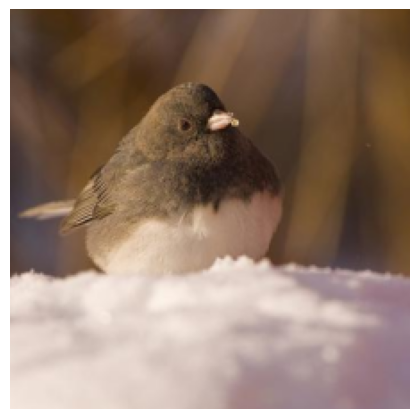

In [17]:
# Ã¢â€â‚¬Ã¢â€â‚¬ Original image Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(img_np)
ax.axis("off")
fig.tight_layout(pad=0)
save(fig, "original")
plt.show()

Saved Ã¢â€ â€™ output\11_multiple_regions\all_regions.png


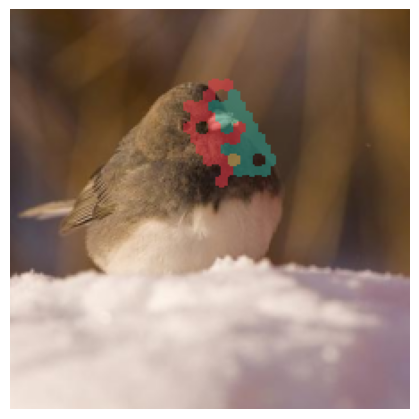

In [18]:
# Ã¢â€â‚¬Ã¢â€â‚¬ All three regions overlaid simultaneously Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
composite = overlay_regions(
    img_np, region_masks, REGION_COLORS[:NUM_REGIONS], REGION_ALPHA
)

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(composite)
ax.axis("off")
fig.tight_layout(pad=0)
save(fig, "all_regions")
plt.show()

## Part B Ã¢â‚¬â€ Seed Selection Heatmap

In [19]:
# Ã¢â€â‚¬Ã¢â€â‚¬ Run model & compute surrogate segment scores Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
with torch.no_grad():
    logits = predictor.get_logits(input_batch)

if TARGET_CLASS_IDX is None:
    target_class_idx = int(logits.argmax(dim=1)[0].item())
else:
    target_class_idx = TARGET_CLASS_IDX

class_label = class_names[target_class_idx] if class_names else str(target_class_idx)
prob = float(torch.softmax(logits, dim=1)[0, target_class_idx].item())
print(f"Target class: [{target_class_idx}] {class_label}  (p = {prob:.3f})")

original_log_odds = log_odds_for_class(logits, target_class_idx)

print("Computing surrogate dataset (this may take a minute)Ã¢â‚¬Â¦")
X, y = create_surrogate_dataset(
    predictor=predictor,
    input_batch=input_batch,
    replacement_image=replacement_image,
    image_graph=image_graph,
    target_class_idx=target_class_idx,
    original_log_odds=original_log_odds,
    neighborhood_distance=NEIGHBORHOOD_DIST,
    batch_size=BATCH_SIZE,
)
scores = calculate_segment_scores(X, y)
print(f"Score range: [{min(scores.values()):.4f}, {max(scores.values()):.4f}]")

Target class: [13] junco  (p = 0.999)
Computing surrogate dataset (this may take a minute)Ã¢â‚¬Â¦
Score range: [-0.5349, 1.7681]


In [20]:
# Ã¢â€â‚¬Ã¢â€â‚¬ Select seed and compute centroids Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
seed_idx, opt_sign = _select_seed_and_sign(
    scores=scores,
    available_segments=list(scores.keys()),
    sigma=SIGMA,
)
seed_neighbors = image_graph.adj_list[seed_idx]

print(
    f"Seed segment : {seed_idx}  (score = {scores[seed_idx]:.4f}, sign = {opt_sign:+d})"
)
print(f"Seed neighbours ({len(seed_neighbors)}): {sorted(seed_neighbors)}")

seed_cx, seed_cy = centroid(seed_idx)

Seed segment : 790  (score = 1.7681, sign = +1)
Seed neighbours (6): [752, 753, 789, 791, 827, 828]


Saved Ã¢â€ â€™ output\11_multiple_regions\seed_selection.png


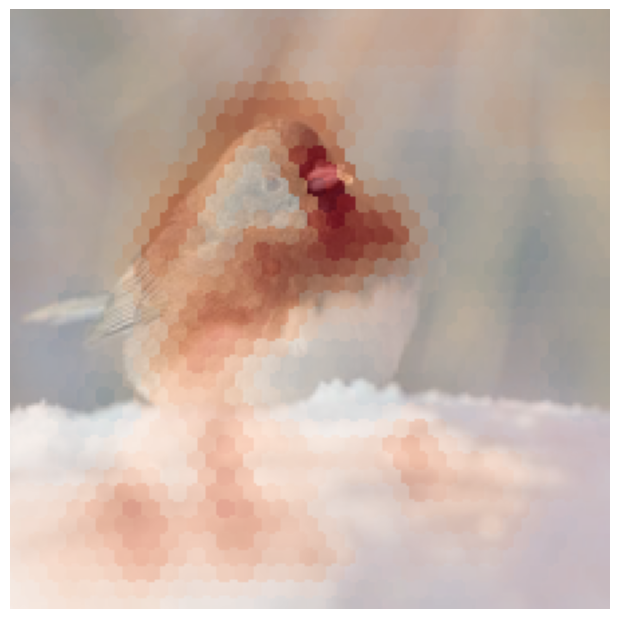

In [23]:
# Ã¢â€â‚¬Ã¢â€â‚¬ Score heatmap + seed/neighbour markers Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
score_map = np.zeros(segs.shape, dtype=np.float32)
for seg_id, score in scores.items():
    score_map[segs == seg_id] = score
abs_max = float(np.abs(score_map).max()) or 1.0

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img_np)
ax.imshow(score_map, cmap="RdBu_r", vmin=-abs_max, vmax=abs_max, alpha=SCORE_ALPHA)
ax.axis("off")

# ax.plot(
#    seed_cx, seed_cy, "*",
#    color="gold", markersize=SEED_MARKER_SIZE,
#    markeredgecolor="black", markeredgewidth=0.6, zorder=5,
# )
# for nb_id in seed_neighbors:
#    nx, ny = centroid(nb_id)
#    ax.plot(
#        nx, ny, "o",
#        color="white", markersize=NEIGHBOR_MARKER_SIZE,
#        markeredgecolor="black", markeredgewidth=0.6, zorder=4,
#    )

fig.tight_layout(pad=0)
save(fig, "seed_selection")
plt.show()

Saved Ã¢â€ â€™ output\11_multiple_regions\seed_selection_boundaries.png


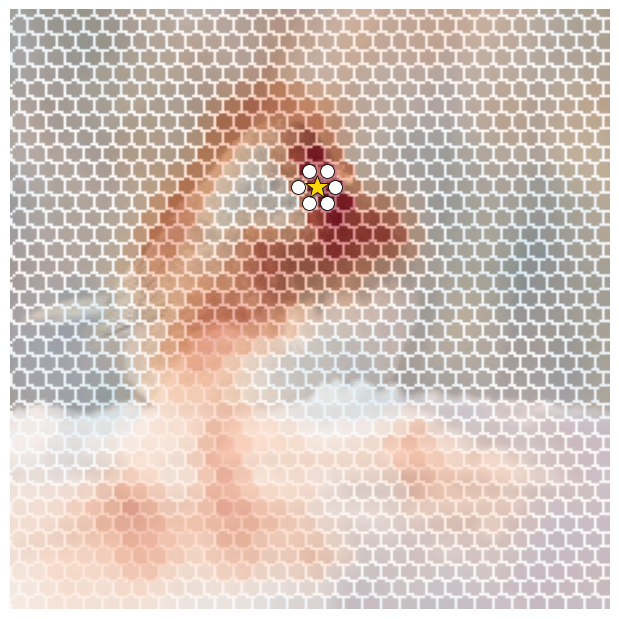

In [22]:
# Ã¢â€â‚¬Ã¢â€â‚¬ Same figure with segment boundaries visible Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
boundaries = _segment_boundaries(segs)
seg_overlay = img_np.copy()
seg_overlay[boundaries] = 1.0

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(seg_overlay)
ax.imshow(score_map, cmap="RdBu_r", vmin=-abs_max, vmax=abs_max, alpha=SCORE_ALPHA)
ax.axis("off")

ax.plot(
    seed_cx,
    seed_cy,
    "*",
    color="gold",
    markersize=SEED_MARKER_SIZE,
    markeredgecolor="black",
    markeredgewidth=0.6,
    zorder=5,
)
for nb_id in seed_neighbors:
    nx, ny = centroid(nb_id)
    ax.plot(
        nx,
        ny,
        "o",
        color="white",
        markersize=NEIGHBOR_MARKER_SIZE,
        markeredgecolor="black",
        markeredgewidth=0.6,
        zorder=4,
    )

fig.tight_layout(pad=0)
save(fig, "seed_selection_boundaries")
plt.show()